In [2]:

from app.utils.Retriever import search_children 

query = "درباره اجزای rag توضیح داده و بگو graphrag چیه"

child_results = search_children(query,collection_name="loader_children" ,top_k=10)

In [11]:
child_results

[ChildSearchResult(parent_title='معماری های پیشرفته RAG', child_title='Graph RAG', child_content='۵.۳  Graph RAG\nGraphRAG   یک رویکرد نوین است که در آن به جای ذخیره صرف قطعات متن، یک گراف دانش\n(Knowledge Graph) از اسناد ساخته می شود.\nدر این گراف:\n•   موجودیت ها (Entities) از منابع مختلف استخراج می شوند\n•   روابط میان آن ها شناسایی و ذخیره می گردد\nاین ساختار برای پرسش هایی که نیاز به ترکیب چندین منبع اطالعاتی دارند بسیار مؤثر است و دقت\nپاسخ دهی را افزایش می دهد.', parent_id='5', child_id='5.3'),
 ChildSearchResult(parent_title='اجزای اصلی یک سیستم   RAG', child_title='پردازش و بارگذاری اسناد   (Document Ingestion)', child_content='۲.۱  پردازش و بارگذاری اسناد   (Document Ingestion)\nاولین گام در ساخت یک سیستم RAG، آماده سازی و بارگذاری اسناد است. در این مرحله، متن خام از\nاسناد استخراج شده، پاک سازی می شود و برای مراحل بعدی آماده می گردد.\nاسناد می توانند در قالب های مختلفی مانند PDF   ، Word   ، HTML، متن ساده و حتی پایگاه های داده\nساخت یافته ارائه شوند. پس از استخراج محتوا، دا

In [2]:
from app.utils.Decider import _format_chunks

a = _format_chunks(child_results)

In [3]:
print(a)

parent title :  معماری های پیشرفته RAG
child title : Graph RAG
child content :
۵.۳  Graph RAG
GraphRAG   یک رویکرد نوین است که در آن به جای ذخیره صرف قطعات متن، یک گراف دانش
(Knowledge Graph) از اسناد ساخته می شود.
در این گراف:
•   موجودیت ها (Entities) از منابع مختلف استخراج می شوند
•   روابط میان آن ها شناسایی و ذخیره می گردد
این ساختار برای پرسش هایی که نیاز به ترکیب چندین منبع اطالعاتی دارند بسیار مؤثر است و دقت
پاسخ دهی را افزایش می دهد.
parent id    :  5
child id    :  5.3

---

parent title :  اجزای اصلی یک سیستم   RAG
child title : پردازش و بارگذاری اسناد   (Document Ingestion)
child content :
۲.۱  پردازش و بارگذاری اسناد   (Document Ingestion)
اولین گام در ساخت یک سیستم RAG، آماده سازی و بارگذاری اسناد است. در این مرحله، متن خام از
اسناد استخراج شده، پاک سازی می شود و برای مراحل بعدی آماده می گردد.
اسناد می توانند در قالب های مختلفی مانند PDF   ، Word   ، HTML، متن ساده و حتی پایگاه های داده
ساخت یافته ارائه شوند. پس از استخراج محتوا، داده ها پردازش شده و برای استفاده در مراحل

In [2]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder(
    "BAAI/bge-reranker-v2-m3"
)

/home/son/Desktop/rag/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 393/393 [00:00<00:00, 1544.76it/s]


In [3]:
from sentence_transformers import CrossEncoder


# بارگذاری مدل Re-ranker
reranker = CrossEncoder(
    "BAAI/bge-reranker-base"
)


def rerank_results(query, child_results, top_k=5):
    
    # ساخت زوج‌های (Query, Document)
    pairs = []

    for item in child_results:
        document = f"""
        موضوع اصلی:
        {item.parent_title}

        بخش:
        {item.child_title}

        محتوا:
        {item.child_content}
        """

        pairs.append(
            (query, document)
        )


    # گرفتن امتیاز ارتباط
    scores = reranker.predict(pairs , batch_size=32 ,  show_progress_bar=False)


    # اضافه کردن امتیاز به نتایج
    ranked_results = []

    for item, score in zip(child_results, scores):
        ranked_results.append(
            {
                "parent_title": item.parent_title,
                "child_title": item.child_title,
                "child_content": item.child_content,
                "parent_id": item.parent_id,
                "child_id": item.child_id,
                "rerank_score": float(score)
            }
        )


    # مرتب سازی بر اساس امتیاز
    ranked_results = sorted(
        ranked_results,
        key=lambda x: x["rerank_score"],
        reverse=True
    )

    # فقط بهترین‌ها
    ranked_results = ranked_results[:top_k]

    # حذف score از خروجی
    for item in ranked_results:
        item.pop("rerank_score")

    return ranked_results

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7100.13it/s]


In [4]:
from app.utils.Retriever import search_children 



query = "درباره پایگاه داده برداری"

child_results = search_children(
    query,
    collection_name="loader_children",
    top_k=10
)




In [5]:
child_results

[ChildSearchResult(parent_title='اجزای اصلی یک سیستم   RAG', child_title='پایگاه داده برداری (Vector Store)', child_content='۲.۴  پایگاه داده برداری (Vector Store)\nالگوریتم های جستجو در پایگاه های داده برداری معموال ً  بر اساس معیارهایی مانند شباهت کسینوسی\n(Cosine Similarity)   یا فاصله اقلیدسی (Euclidean Distance) عمل می کنند. برای مقیاس ،های بزرگ\nاز الگوریتم هایی نظیرHNSW (Hierarchical Navigable Small World)   وIVF (Inverted File Index)\nاستفاده  می شود  که  جستجوی  تقریبی  نزدیک ترین  همسایه ها (ANN - Approximate Nearest\nNeighbor) را با سرعت بسیار باال انجام می دهند.', parent_id='2', child_id='2.5'),
 ChildSearchResult(parent_title='اجزای اصلی یک سیستم   RAG', child_title='بازیابی و رتبه بندی (Retrieval & Reranking)', child_content='۲.۵  بازیابی و رتبه بندی (Retrieval & Reranking)\nهنگامی که کاربر سؤالی مطرح می کند، ابتدا سؤال به یک بردار عددی تبدیل می شود. سپس این بردار\nدر پایگاه داده برداری جستجو شده و نزدیک ترین قطعات متن به آن بازیابی می شوند.\nً در این مرحله معموالk قطعه ب

In [6]:
top_results = rerank_results(
    query,
    child_results,
    top_k=5
)


for r in top_results:
    print("------------------")
    print(r["child_title"])
    # print(r["rerank_score"])

------------------
مقدمه و پیشینه
------------------
پایگاه داده برداری (Vector Store)
------------------
پردازش و بارگذاری اسناد   (Document Ingestion)
------------------
Graph RAG
------------------
آینده    RAG


In [ ]:
# def pair(query,child_results):
    
#     # ساخت زوج‌های (Query, Document)
#     pairs = []

#     for item in child_results:
#         document = f"""
#         موضوع اصلی:
#         {item.parent_title}

#         بخش:
#         {item.child_title}

#         محتوا:
#         {item.child_content}
#         """

#         pairs.append(
#             (query, document)
#         )
    
#     return pairs
# pairs = pair(query , child_results)

In [ ]:
# import time

# t0 = time.perf_counter()

# scores = reranker.predict(
#     pairs,
#     batch_size=10,
#     show_progress_bar=False
# )

# t1 = time.perf_counter()

# print(f"Predict time: {t1 - t0:.3f} s")

Predict time: 3.331 s


In [137]:
child_results

[ChildSearchResult(parent_title='چالش های RAG برای زبان فارسی', child_title='چندریختی متن فارسی', child_content='۳.۱    چندریختی متن فارسی\nزبان فارسی دارای اشکال مختلف نوشتاری برای برخی کاراکترها است. برای مثال، حرف «ک» ممکن\nاست به صورت «ك» (عربی) نیز نوشته شود. همچنین کاراکترهای «ی»، «ي» و «ئ» در برخی موارد معادل\nیکدیگر در نظر گرفته می شوند.\nاین موضوع می ،تواند باعث عدم تطابق متون هنگام جستجو و بازیابی اطالعات شود. برای رفع این مشکل\nالزم است پیش از تبدیل متن به بردار، مرحله ای تحت عنوان نرمال سازی متن (Text Normalization)\nانجام شود تا تمامی کاراکترها به یک قالب استاندارد تبدیل شوند.', parent_id='3', child_id='3.2'),
 ChildSearchResult(parent_title='پیاده سازی عملی با LangChain', child_title='پیاده سازی عملی با LangChain', child_content='LangChain یکی از پرکاربردترین چارچوب ها برای ساخت سیستم های RAG   است. در ادامه یک نمونه\nساده از پیاده سازی این معماری ارائه می شود.\nمرحله۱: بارگذاری اسناد\nدر این مرحله از کالس های loader   مانندPyPDFLoader   یاDirectoryLoader   برای خواندن اس

In [138]:
top_results

[{'parent_title': 'چالش های RAG برای زبان فارسی',
  'child_title': 'چندریختی متن فارسی',
  'child_content': '۳.۱    چندریختی متن فارسی\nزبان فارسی دارای اشکال مختلف نوشتاری برای برخی کاراکترها است. برای مثال، حرف «ک» ممکن\nاست به صورت «ك» (عربی) نیز نوشته شود. همچنین کاراکترهای «ی»، «ي» و «ئ» در برخی موارد معادل\nیکدیگر در نظر گرفته می شوند.\nاین موضوع می ،تواند باعث عدم تطابق متون هنگام جستجو و بازیابی اطالعات شود. برای رفع این مشکل\nالزم است پیش از تبدیل متن به بردار، مرحله ای تحت عنوان نرمال سازی متن (Text Normalization)\nانجام شود تا تمامی کاراکترها به یک قالب استاندارد تبدیل شوند.',
  'parent_id': '3',
  'child_id': '3.2'},
 {'parent_title': 'اجزای اصلی یک سیستم   RAG',
  'child_title': 'پایگاه داده برداری (Vector Store)',
  'child_content': '۲.۴  پایگاه داده برداری (Vector Store)\nالگوریتم های جستجو در پایگاه های داده برداری معموال ً  بر اساس معیارهایی مانند شباهت کسینوسی\n(Cosine Similarity)   یا فاصله اقلیدسی (Euclidean Distance) عمل می کنند. برای مقیاس ،های بزرگ\nاز الگوریتم ه

In [ ]:
import importlib
import test.newdecid as newdecid

importlib.reload(newdecid)

from test.newdecid import format_chunks
b = format_chunks(top_results)

In [160]:
print(b)

parent title : چالش های RAG برای زبان فارسی
child title : چندریختی متن فارسی
child content :
۳.۱    چندریختی متن فارسی
زبان فارسی دارای اشکال مختلف نوشتاری برای برخی کاراکترها است. برای مثال، حرف «ک» ممکن
است به صورت «ك» (عربی) نیز نوشته شود. همچنین کاراکترهای «ی»، «ي» و «ئ» در برخی موارد معادل
یکدیگر در نظر گرفته می شوند.
این موضوع می ،تواند باعث عدم تطابق متون هنگام جستجو و بازیابی اطالعات شود. برای رفع این مشکل
الزم است پیش از تبدیل متن به بردار، مرحله ای تحت عنوان نرمال سازی متن (Text Normalization)
انجام شود تا تمامی کاراکترها به یک قالب استاندارد تبدیل شوند.
parent id : 3
child id : 3.2

---

parent title : اجزای اصلی یک سیستم   RAG
child title : پایگاه داده برداری (Vector Store)
child content :
۲.۴  پایگاه داده برداری (Vector Store)
الگوریتم های جستجو در پایگاه های داده برداری معموال ً  بر اساس معیارهایی مانند شباهت کسینوسی
(Cosine Similarity)   یا فاصله اقلیدسی (Euclidean Distance) عمل می کنند. برای مقیاس ،های بزرگ
از الگوریتم هایی نظیرHNSW (Hierarchical Navigable Small World) 

In [ ]:
import importlib
import test.newdecid as newdecid

importlib.reload(newdecid)

from test.newdecid import evaluate_retrieved_raw_text

In [142]:
ids = evaluate_retrieved_raw_text(query, b)

In [143]:
ids

{'parent_ids': ['3'], 'child_ids': ['2.5', '2.4'], 'retry': False}

In [ ]:
from test.newdecid import build_context

full_context = build_context(ids , top_results ,)

In [5]:
import markdown
from IPython.display import display, HTML

def print_md(content):
    content = markdown.markdown(content)
    content = "<div dir=rtl>{}</div>".format(content)
    display(HTML(content))

print_md(full_context)

NameError: name 'full_context' is not defined

In [1]:
import importlib
import app.rag.query_transformer

importlib.reload(app.rag.query_transformer)

from app.rag.query_transformer import route_query

query_transform=route_query('درباره استریم بودن پیام بگو')

/home/son/Desktop/rag/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
query_transform

{'tool_used': 'multiquery',
 'result': {'queries': ['استریم بودن پیام به چه معناست؟',
   'مفهوم stream بودن پیام چیست؟',
   'پیام\u200cها چگونه به صورت stream ارسال می\u200cشوند؟',
   'تعریف stream بودن پیام در سیستم\u200cها چیست؟',
   'What does it mean for a message to be streamed?']}}

In [148]:
TRANSFORM_TOP_K = 1
all_new_child_results = []

for q in query_transform["result"]["queries"]:
    results = search_children(
        query=q,
        collection_name="loader_children",
        top_k=TRANSFORM_TOP_K,
    )
    all_new_child_results.extend(results)

In [149]:
unique_child_results = list(
    {item.child_id: item for item in all_new_child_results}.values()
)

In [150]:
unique_child_results

[ChildSearchResult(parent_title='چالش های RAG برای زبان فارسی', child_title='راست به چپ بودن متن', child_content='۳.۴  راست به چپ بودن متن\nمتن فارسی در رابط های کاربری و گزارش ها نیازمند پشتیبانی از نمایش راست به چپ (RTL - Right-\nto-Left) است. در پیاده سازی های فنی، باید اطمینان حاصل شود که تمامی مراحل پردازش، ذخیره سازی\nو نمایش داده ها از این ویژگی پشتیبانی می کنند.\nعدم توجه به این موضوع می تواند منجر به نمایش نادرست متن، به هم ریختگی رابط کاربری و کاهش\nتجربه کاربری شود.', parent_id='3', child_id='3.5'),
 ChildSearchResult(parent_title='آینده    RAG', child_title='آینده    RAG', child_content='آینده RAG به سمت سیستم های پیشرفته تر و هوشمندتر در حال حرکت است، از جمله:\n•   Streaming RAG: تولید پاسخ به صورت تدریجی\n•   Multimodal RAG:   پردازش همزمان متن، تصویر، جدول و نمودار\n•   RAG با حافظه بلندمدت: نگهداری تاریخچه مکالمات و استفاده از آن در پاسخ ها\nبا افزایش ظرفیت مدل های زبانی و گسترش پنجره زمینه (Context Window)  ، برخی کاربردهای\nسنتی RAG ممکن است تغییر کنند، اما در سیستم ه

In [151]:
parent_ids = ["1" , "3"]
child_ids = ["9.1"]

parent_ids_set = set(parent_ids)
child_ids_set = set(child_ids)

filtered_child_results = [
    item
    for item in unique_child_results
    if item.parent_id not in parent_ids_set
    and item.child_id not in child_ids_set
]
filtered_child_results

[ChildSearchResult(parent_title='اجزای اصلی یک سیستم   RAG', child_title='تقسیم بندی متن (Chunking)', child_content='۲.۲  تقسیم بندی متن (Chunking)\nپس از بارگذاری اسناد، متن ها به قطعات کوچک تری به نامChunk تقسیم می شوند. این کار به دلیل\nمحدودیت پنجره زمینه (Context Window) مدل های زبانی ضروری است.\nاستراتژی های متداول تقسیم بندی عبارت اند از:\nالف) تقسیم بندی با اندازه ثابت (Fixed-size Chunking)\nدر این روش، متن به قطعاتی با تعداد ثابتی از کاراکترها یا توکن ها تقسیم می شود. این روش ساده و\nسریع است، اما ممکن است جمالت یا پاراگراف ها را از یکدیگر جدا کرده و انسجام معنایی متن را\nکاهش دهد.\nب) تقسیم بندی معنایی (Semantic Chunking)\nدر این رویکرد،  قطعات  بر اساس  مرزهای معنایی مانند  پاراگراف ها،  بخش ها  یا موضوعات  ایجاد\nمی شوند.  این  روش  کیفیت  باالتری  دارد،  زیرا  ارتباط  مفهومی  میان  اجزای  متن  حفظ  می شود،  اما\nپیاده سازی آن پیچیده تر است.\nج) تقسیم بندی با هم پوشانی (Overlapping Chunks)\nبرای حفظ زمینه در مرزهای بین قطعات، از هم پوشانی استفاده می شود. به عنوان مثال، اگر 

In [ ]:
from test.newdecid import format_chunks
c = format_chunks(filtered_child_results)

In [161]:
print(c)

parent title : اجزای اصلی یک سیستم   RAG
child title : تقسیم بندی متن (Chunking)
child content :
۲.۲  تقسیم بندی متن (Chunking)
پس از بارگذاری اسناد، متن ها به قطعات کوچک تری به نامChunk تقسیم می شوند. این کار به دلیل
محدودیت پنجره زمینه (Context Window) مدل های زبانی ضروری است.
استراتژی های متداول تقسیم بندی عبارت اند از:
الف) تقسیم بندی با اندازه ثابت (Fixed-size Chunking)
در این روش، متن به قطعاتی با تعداد ثابتی از کاراکترها یا توکن ها تقسیم می شود. این روش ساده و
سریع است، اما ممکن است جمالت یا پاراگراف ها را از یکدیگر جدا کرده و انسجام معنایی متن را
کاهش دهد.
ب) تقسیم بندی معنایی (Semantic Chunking)
در این رویکرد،  قطعات  بر اساس  مرزهای معنایی مانند  پاراگراف ها،  بخش ها  یا موضوعات  ایجاد
می شوند.  این  روش  کیفیت  باالتری  دارد،  زیرا  ارتباط  مفهومی  میان  اجزای  متن  حفظ  می شود،  اما
پیاده سازی آن پیچیده تر است.
ج) تقسیم بندی با هم پوشانی (Overlapping Chunks)
برای حفظ زمینه در مرزهای بین قطعات، از هم پوشانی استفاده می شود. به عنوان مثال، اگر اندازه هر
قطعه۵۰۰    توکن باشد، م

In [7]:
from app.agent.agent import run_agent

In [8]:
new = run_agent("پایگاه داده برداری چیه")

In [1]:
import importlib
import app.agent.graph

importlib.reload(app.agent.graph)

from app.agent.graph import graph

/home/son/Desktop/rag/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5103.70it/s]


In [4]:
result = graph.invoke({
    "query": "درباره مشکل چندریخت بودن زبان فارسی بگو "
})

In [3]:
result

{'query': 'درباره مشکل چندریخت بودن زبان فارسی بگو ',
 'parent_ids': [],
 'child_ids': ['3.2'],
 'context': '### [3.2] چندریختی متن فارسی\n۳.۱    چندریختی متن فارسی\nزبان فارسی دارای اشکال مختلف نوشتاری برای برخی کاراکترها است. برای مثال، حرف «ک» ممکن\nاست به صورت «ك» (عربی) نیز نوشته شود. همچنین کاراکترهای «ی»، «ي» و «ئ» در برخی موارد معادل\nیکدیگر در نظر گرفته می شوند.\nاین موضوع می ،تواند باعث عدم تطابق متون هنگام جستجو و بازیابی اطالعات شود. برای رفع این مشکل\nالزم است پیش از تبدیل متن به بردار، مرحله ای تحت عنوان نرمال سازی متن (Text Normalization)\nانجام شود تا تمامی کاراکترها به یک قالب استاندارد تبدیل شوند.',
 'answer': 'بر اساس بخش ۳.۲ مستندات سیستم\u200cهای RAG، زبان فارسی دارای اشکال مختلف نوشتاری برای برخی کاراکترها است که به آن چندریختی متن فارسی گفته می\u200cشود. برای مثال، حرف «ک» ممکن است به صورت «ك» (عربی) نیز نوشته شود و همچنین کاراکترهای «ی»، «ي» و «ئ» در برخی موارد معادل یکدیگر در نظر گرفته می\u200cشوند. این چندریختی می\u200cتواند باعث عدم تطابق متون هنگام جستجو و ب

In [9]:
import markdown
from IPython.display import display, HTML

def print_md(content):
    content = markdown.markdown(content)
    content = "<div dir=rtl>{}</div>".format(content)
    display(HTML(content))

print_md(new['answer'])

/home/son/Desktop/rag/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 18 files: 100%|██████████| 18/18 [00:01<00:00, 12.52it/s]


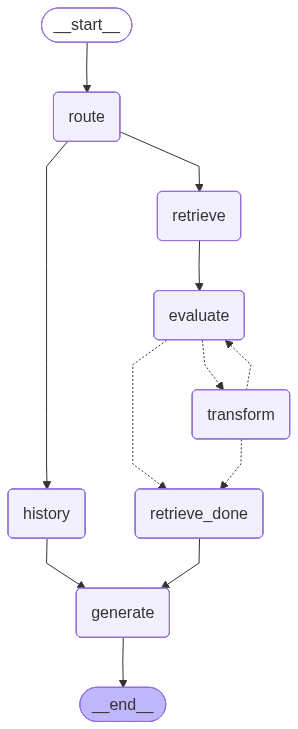

In [1]:
from app.agent.graph import graph

from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
s = "بر اساس بخش ۵.۳ مستندات ارائه شده، GraphRAG یک رویکرد نوین در سیستم‌های RAG است که به جای ذخیره صرف قطعات متن، یک گراف دانش (Knowledge Graph) از اسناد ساخته می‌شود. در این گراف، موجودیت‌ها (Entities) از منابع مختلف استخراج شده و روابط میان آن‌ها شناسایی و ذخیره می‌گردد. این ساختار برای پرسش‌هایی که نیاز به ترکیب چندین منبع اطلاعاتی دارند بسیار مؤثر است و دقت پاسخ‌دهی را افزایش می‌دهد."


In [11]:
import markdown
from IPython.display import display, HTML

def print_md(content):
    content = markdown.markdown(content)
    content = "<div dir=rtl>{}</div>".format(content)
    display(HTML(content))

print_md(s)

In [ ]:
pairs = []
for chunk in child_results:
    pairs.append((query, chunk["content"]))

scores = reranker.predict(pairs)

In [10]:
from collections import defaultdict

# child_results = خروجی Search

parents = defaultdict(list)

for child in child_results:
    parents[child.parent_id].append({
        "child_id": child.child_id,
        "child_title": child.child_title,
        "child_content": child.child_content,
    })

In [11]:
contexts = []

for parent_id, children in parents.items():

    parent_title = next(
        c.parent_title
        for c in child_results
        if c.parent_id == parent_id
    )

    text = f"Parent Title:\n{parent_title}\n\n"

    text += "Children:\n"

    for i, child in enumerate(children, start=1):
        text += (
            f"\n[{i}]\n"
            f"Child ID: {child['child_id']}\n"
            f"Title: {child['child_title']}\n"
            f"Content:\n{child['child_content']}\n"
        )

    contexts.append({
        "parent_id": parent_id,
        "context": text
    })

In [13]:
contexts[0]

{'parent_id': '2',
 'context': 'Parent Title:\nاجزای اصلی یک سیستم   RAG\n\nChildren:\n\n[1]\nChild ID: 2.1\nTitle: مقدمه ای برای: اجزای اصلی یک سیستم   RAG\nContent:\nیک سیستم RAG   از چندین مؤلفه کلیدی تشکیل شده است که هر یک نقش مهمی در کیفیت نهایی\nپاسخ ها ایفا می کنند.\n\n[2]\nChild ID: 2.2\nTitle: پردازش و بارگذاری اسناد   (Document Ingestion)\nContent:\n۲.۱  پردازش و بارگذاری اسناد   (Document Ingestion)\nاولین گام در ساخت یک سیستم RAG، آماده سازی و بارگذاری اسناد است. در این مرحله، متن خام از\nاسناد استخراج شده، پاک سازی می شود و برای مراحل بعدی آماده می گردد.\nاسناد می توانند در قالب های مختلفی مانند PDF   ، Word   ، HTML، متن ساده و حتی پایگاه های داده\nساخت یافته ارائه شوند. پس از استخراج محتوا، داده ها پردازش شده و برای استفاده در مراحل بعدی\nسیستم آماده می شوند.\n\n[3]\nChild ID: 2.7\nTitle: تولید پاسخ (Generation)\nContent:\n۲.۶    تولید پاسخ (Generation)\nدر مرحله نهایی، سؤال اصلی کاربر به همراه قطعات بازیابی شده به عنوانPrompt   به مدل زبانی بزرگ\nارسال می شود.\nساختار P